In [1]:
#!csharp
System.Console.WriteLine("Hello C#");

Hello C#


## Install openCVSharp4 

In [4]:
#r "nuget: OpenCvSharp4, 4.13.0.20260602"
#r "nuget: OpenCvSharp4.official.runtime.linux-x64, 4.13.0.20260602"
#!csharp
using OpenCvSharp;
System.Console.WriteLine($"OpenCV Version: {Cv2.GetVersionString()}");

Installed Packages OpenCvSharp4, 4.13.0.20260602 OpenCvSharp4.official.runtime.linux-x64, 4.13.0.20260602

OpenCV Version: 4.13.0


In [9]:
Mat Color = new Mat(new Size(width: 640, height: 480), MatType.CV_8UC3, Scalar.All(0)); // Create a black image of size 640x480 with 3 channels (BGR) and 8-bit unsigned integers
Mat gray = new Mat(new Size(width: 640, height: 480), MatType.CV_8UC1, Scalar.All(0)); // Create a black image of size 640x480 with 1 channel (grayscale) and 8-bit unsigned integers

In [10]:
Console.WriteLine($"Color Image Size: {Color.Size()}");
Console.WriteLine($"Gray Image Size: {gray.Size()}");

Color Image Size: Size { Width = 640, Height = 480 }
Gray Image Size: Size { Width = 640, Height = 480 }


## 히스토그램 예시

Loaded image: ../../sample/lenna.png


Gray + Histogram
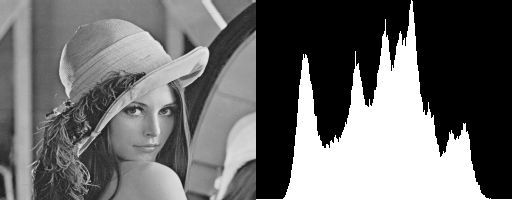

Image Size: 512x480
Histogram bins: 256
Peak bin intensity: 155, normalized peak: 200.00


In [20]:
#!csharp
using System;
using System.IO;
using System.Linq;
using OpenCvSharp;
using Microsoft.DotNet.Interactive;
using Microsoft.DotNet.Interactive.Formatting;

// 1) 이미지 경로 후보를 순서대로 검사해서 첫 번째 유효 경로를 사용
string[] candidates =
{
    "../../../../sample/lenna.png",
    "../../../sample/lenna.png",
    "../../sample/lenna.png",
    "../sample/lenna.png",
    "sample/lenna.png"
};

string? imagePath = candidates.FirstOrDefault(File.Exists);
Mat src;

if (imagePath is null)
{
    // 2) 파일이 없으면 테스트용 그라디언트 이미지를 만들어 셀이 항상 실행되도록 함
    Console.WriteLine("lenna.png를 찾지 못해 테스트용 이미지를 생성합니다.");
    src = new Mat(new Size(640, 480), MatType.CV_8UC3);
    for (int y = 0; y < src.Rows; y++)
    {
        byte v = (byte)(y * 255 / Math.Max(1, src.Rows - 1));
        Cv2.Line(src, new Point(0, y), new Point(src.Cols - 1, y), new Scalar(v, v, v), 1);
    }
}
else
{
    // 3) 유효한 경로의 이미지를 로드
    src = Cv2.ImRead(imagePath, ImreadModes.Color);
    Console.WriteLine($"Loaded image: {imagePath}");
}

if (src.Empty())
    throw new Exception("소스 이미지가 비어 있습니다. 경로 또는 파일을 확인하세요.");

// 4) 그레이 변환 후 256-bin 히스토그램 계산
Mat gray = new Mat();
Mat hist = new Mat();
Cv2.CvtColor(src, gray, ColorConversionCodes.BGR2GRAY);
Cv2.CalcHist(
    new[] { gray },
    new[] { 0 },
    null,
    hist,
    1,
    new[] { 256 },
    new[] { new Rangef(0, 256) }
);

// 5) 시각화를 위해 히스토그램 값을 그래프 높이(0~200)로 정규화
int histHeight = 200;
Cv2.Normalize(hist, hist, 0, histHeight, NormTypes.MinMax);

// 6) 히스토그램 그래프 이미지를 생성 (검은 배경 + 흰색 막대)
Mat histImage = new Mat(new Size(256, histHeight), MatType.CV_8UC3, Scalar.All(0));
for (int i = 0; i < 256; i++)
{
    int h = (int)Math.Round(hist.Get<float>(i));
    Cv2.Line(
        histImage,
        new Point(i, histHeight - 1),
        new Point(i, Math.Max(0, histHeight - 1 - h)),
        new Scalar(255, 255, 255),
        1
    );
}

// 7) 원본 그레이 이미지(왼쪽)와 히스토그램(오른쪽)을 같은 높이/채널로 맞춰 합치기
Mat grayResized = new Mat();
Cv2.Resize(gray, grayResized, new Size(256, histHeight));
Mat grayColor = new Mat();
Cv2.CvtColor(grayResized, grayColor, ColorConversionCodes.GRAY2BGR);

Mat merged = new Mat();
Cv2.HConcat(new[] { grayColor, histImage }, merged);

// 8) 노트북 출력에 인라인 이미지로 표시
Cv2.ImEncode(".png", merged, out byte[] pngBytes);
string base64 = Convert.ToBase64String(pngBytes);
var html = $"<div><h4>Gray + Histogram</h4><img src='data:image/png;base64,{base64}' /></div>";
Kernel.display(HTML(html));

// 9) 요약 정보도 텍스트로 함께 출력
Cv2.MinMaxLoc(hist, out double minVal, out double maxVal, out _, out Point maxLoc);
Console.WriteLine($"Image Size: {src.Cols}x{src.Rows}");
Console.WriteLine($"Histogram bins: {hist.Rows}");
Console.WriteLine($"Peak bin intensity: {maxLoc.Y}, normalized peak: {maxVal:F2}");

gray.Dispose();
hist.Dispose();
histImage.Dispose();
grayResized.Dispose();
grayColor.Dispose();
merged.Dispose();
src.Dispose();